# Lion Attacks

Humanity has long feared the dark because of night-time predators. Nocturnal hunters, such as lions, have excellent low-light vision. In this project, we will investigate the influence of moonlight on hunting activity.

### Loading the Data
Most lion attacks targeting humans occur in the evening, defined here as 6pm to 10pm, after which humans are typically indoors and asleep.

The `lion-attacks-lunar-cycle.csv` file contains the number of lion attacks on humans for each day of the lunar cycle. The Moon completes a lunar cycle every 29.5 days, transitioning from a new moon to a full moon and then back to a new moon.

Load the data and take a look.

Activity Goals:
- Load the lion attack data.
- Display the dataframe.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('lion-attacks-lunar-cycle.csv')
df #display dataframe

,lunar_day,evening_moonlight,attacks
0,0,0.000,10
1,1,0.010,9
2,2,0.038,10
3,3,0.100,11
4,4,0.170,6
...,...,...,...
25,25,0.000,12
26,26,0.000,8
27,27,0.000,10
28,28,0.000,9


The variable `evening_moonlight` represents how bright the moon is during the evening hours from 6pm to 10pm. It ranges from 0 (not visible at all) to 1 (maximum brightness), which is affected by two factors:

- The phase of the moon
- The number of hours the moon is visible during the early night.

For almost half the lunar month there is no evening moonlight - on those days the moon rises after 10pm.

### Lion attacks vs Moonlight
Let's graph a scatter plot between lion attacks and moonlight levels.

Activity Goals:
- Create scatter plot of evening moonlight vs number of attacks.
- Label the axes.

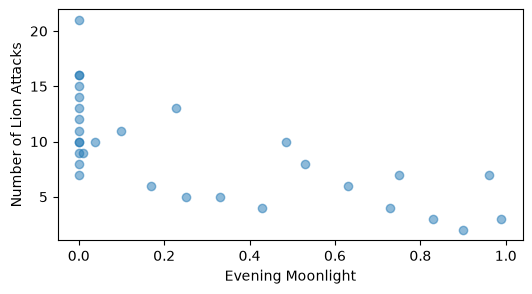

In [28]:
plt.figure(figsize=(6, 3))
plt.scatter(df['evening_moonlight'], df['attacks'], alpha=0.5)
plt.xlabel('Evening Moonlight')
plt.ylabel('Number of Lion Attacks')
plt.show()

The graph shows that as the moonlight levels increase, evening lion attacks decrease. This indicates a negative relationship.

### Correlation or Causation?
Why are there fewer attacks when the moon is bright? Does the brighter moon directly cause fewer attacks? Or maybe moonlight and attacks are both being influenced by some other factor?

In data science there is an important mantra: "correlation does not imply causation".

To strengthen a causation argument, we look for two things:

- A plausible mechanism that explains the relationship
- Independent supporting evidence

One plausible mechanism for the relationship is that moonlight also helps humans see lions at night and avoid attacks.

We have a plausible mechanism, now we need to find supporting evidence using an independent dataset.

### Lion belly data
Lions can consume up to a quarter of their body weight in a single meal! To accommodate this, their stomachs swell noticeably. Since 1978, scientists in Tanzania have estimated the belly sizes of adult lions (as viewed from a safe distance!) to get a measure of how much they ate the previous night (other animals, not people!).

The `lion-belly-sizes.csv` file contains belly size estimates averaged over 11,000 sightings. Belly size ranges from 0 to 1 (empty to fully swollen). The moonlight level is estimated from the lunar cycle and takes into account the phase of the moon and the number of hours the moon is visible from 6pm to 6am.

Load in the data and take a look!

Activity Goals:
- Load the new dataset.
- Assign it to the variable `df_belly`.
- Display the dataframe.

In [29]:
df_belly = pd.read_csv('lion-belly-sizes.csv')
df_belly #display the dataframe

,lunar_day,moonlight,belly_size
0,0,0.000,0.5005
1,1,0.003,0.5073
2,2,0.013,0.5032
3,3,0.033,0.4926
4,4,0.071,0.4897
...,...,...,...
25,25,0.040,0.5044
26,26,0.023,0.5115
27,27,0.007,0.5004
28,28,0.001,0.4969


The average belly size is for each lunar day is around 0.5.

Let's see if this data supports the causation hypothesis that moonlight decreases hunting success of lions.

### Plotting belly sizes vs Moonlight

First we will create a scatterplot of the belly data, with moonlight levels on the x-axis.

Activity Goals:
- Plot belly size vs moonlight.
- Label the axes.

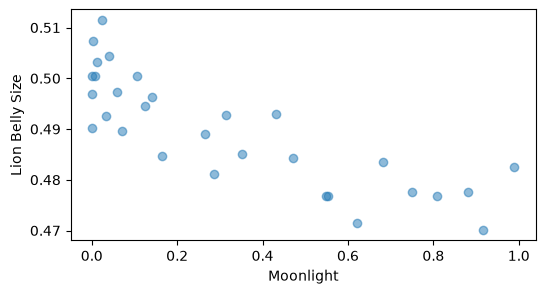

In [30]:
plt.figure(figsize=(6, 3))
plt.scatter(df_belly['moonlight'], df_belly['belly_size'], alpha=0.5)
plt.xlabel('Moonlight')
plt.ylabel('Lion Belly Size')
plt.show()

The relationship is negative: as moonlight increases, lion belly size tends to decrease. As the moonlight levels increase, average lion belly size decreases, indicating they had less to eat. 

### Conclusion

More moonlight = fewer lion attacks because lions are easier to see in bright nights.
On bright nights, lions hunt less, so their bellies become smaller and they get hungry.
After a full moon, the moon rises later, so the evenings become dark again.
But the lions are still hungry from the previous bright nights.
Therefore, hungry lions + dark evenings = more attacks.

So, moonlight affects attacks in two ways:

Directly: Bright light makes lions easier to see, so they attack less.
Indirectly: Bright nights make lions hunt less and become hungry, causing more attacks when dark nights return.

Therefore, the belly data supports the idea that moonlight is related to lion attacks through a possible causal mechanism, not just correlation.